In [1]:
import os
import re
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from jiwer import wer, cer

In [10]:
pages = [78, 94]

project_root = "../../"

old_outputs = {
    "PaddleOCR": {
        78: os.path.join(
            project_root,
            "PaddleOCR/outputs/Experiment_1/page_78.txt"
        ),
        94: os.path.join(
            project_root,
            "PaddleOCR/outputs/Experiment_1/page_94.txt"
        )
    },
    "Gemini 3.1 Pro": {
        78: os.path.join(
            project_root,
            "Gemini_3.1_Pro/outputs/Experiment_1/page_78.txt"
        ),
        94: os.path.join(
            project_root,
            "Gemini_3.1_Pro/outputs/Experiment_1/page_94.txt"
        )
    }
}

improved_outputs = {
    "PaddleOCR": {
        78: "PaddleOCR/Output_improvement/experiment_files/78_original.txt",
        94: "PaddleOCR/Output_improvement/experiment_files/94_original_2.txt"
    },
    "Gemini 3.1 Pro": {
        78: "Gemini_3.1_Pro/Output_improvement/experiment_files/78_run_4.txt",
        94: "Gemini_3.1_Pro/Output_improvement/experiment_files/94_run_4.txt"
    }
}

In [11]:
import os

print(os.getcwd())

for model in old_outputs:
    for p in pages:
        print(
            "OLD",
            model,
            p,
            os.path.exists(old_outputs[model][p])
        )

for model in improved_outputs:
    for p in pages:
        print(
            "IMPROVED",
            model,
            p,
            os.path.exists(improved_outputs[model][p])
        )

C:\Users\wasik\Desktop\thesis_project2\Case_Specific_experiment\Recognition_Improvement_experiment
OLD PaddleOCR 78 True
OLD PaddleOCR 94 True
OLD Gemini 3.1 Pro 78 True
OLD Gemini 3.1 Pro 94 True
IMPROVED PaddleOCR 78 True
IMPROVED PaddleOCR 94 True
IMPROVED Gemini 3.1 Pro 78 True
IMPROVED Gemini 3.1 Pro 94 True


In [12]:
def normalize_text(text):
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [13]:
gold_base = "https://nlp.fi.muni.cz/projekty/ahisto/ocr-output/494/"

comparison_results = []

for model in ["PaddleOCR", "Gemini 3.1 Pro"]:
    for p in pages:

        gold_url = f"{gold_base}{p}.txt"
        gold_text = requests.get(gold_url).text
        gold_norm = normalize_text(gold_text)

        # Previous result
        with open(old_outputs[model][p], "r", encoding="utf-8") as f:
            old_text = normalize_text(f.read())

        old_wer = wer(gold_norm, old_text)
        old_cer = cer(gold_norm, old_text)

        comparison_results.append({
            "Model": model,
            "Page": p,
            "Condition": "Previous",
            "WER": old_wer,
            "CER": old_cer
        })

        # Improved result
        with open(improved_outputs[model][p], "r", encoding="utf-8") as f:
            improved_text = normalize_text(f.read())

        improved_wer = wer(gold_norm, improved_text)
        improved_cer = cer(gold_norm, improved_text)

        comparison_results.append({
            "Model": model,
            "Page": p,
            "Condition": "Improved",
            "WER": improved_wer,
            "CER": improved_cer
        })

In [17]:
df_comparison = pd.DataFrame(comparison_results)

df_comparison["WER (%)"] = df_comparison["WER"] * 100
df_comparison["CER (%)"] = df_comparison["CER"] * 100

df_comparison

,Model,Page,Condition,WER,CER,WER (%),CER (%)
0,PaddleOCR,78,Previous,0.520863,0.405079,52.086331,40.507860
1,PaddleOCR,78,Improved,0.087770,0.042563,8.776978,4.256348
2,PaddleOCR,94,Previous,0.348485,0.224595,34.848485,22.459459
3,PaddleOCR,94,Improved,0.350168,0.224865,35.016835,22.486486
4,Gemini 3.1 Pro,78,Previous,0.517986,0.390326,51.798561,39.032648
5,Gemini 3.1 Pro,78,Improved,0.053237,0.018138,5.323741,1.813785
6,Gemini 3.1 Pro,94,Previous,0.217172,0.095676,21.717172,9.567568
7,Gemini 3.1 Pro,94,Improved,0.124579,0.039459,12.457912,3.945946


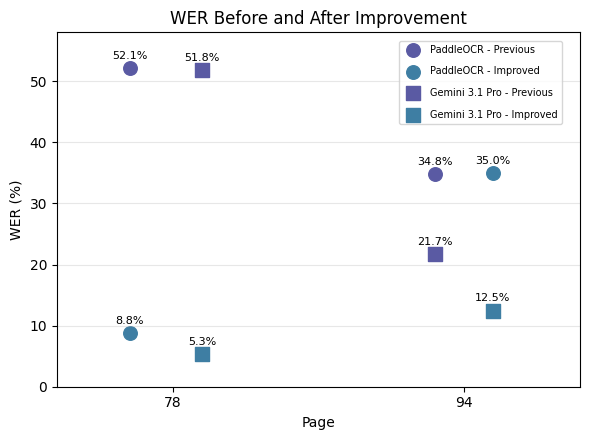

In [92]:
plt.figure(figsize=(6, 4.5))

page_positions = {
    78: 0,
    94: 0.10
}

colors = {
    "Previous": "#5A5AA3",   # purple
    "Improved": "#3E7EA3"    # blue
}
series = [
    ("PaddleOCR", "Previous", "o"),
    ("PaddleOCR", "Improved", "o"),
    ("Gemini 3.1 Pro", "Previous", "s"),
    ("Gemini 3.1 Pro", "Improved", "s")
]

point_offsets = {
    # Page 78
    (78, "PaddleOCR", "Previous"): -0.015,
    (78, "PaddleOCR", "Improved"): -0.015,
    (78, "Gemini 3.1 Pro", "Previous"): 0.010,
    (78, "Gemini 3.1 Pro", "Improved"): 0.010,

    # Page 94
    (94, "PaddleOCR", "Previous"): -0.010,
    (94, "PaddleOCR", "Improved"): 0.010,
    (94, "Gemini 3.1 Pro", "Previous"): -0.010,
    (94, "Gemini 3.1 Pro", "Improved"): 0.010
}

for model, condition, marker in series:

    subset = df_comparison[
        (df_comparison["Model"] == model) &
        (df_comparison["Condition"] == condition)
    ].copy()

    subset["x"] = subset["Page"].map(page_positions)

    first_point = True

    for _, row in subset.iterrows():
    
        offset = point_offsets[
            (row["Page"], model, condition)
        ]
    
        x_pos = row["x"] + offset
    
        plt.scatter(
            x_pos,
            row["WER (%)"],
            marker=marker,
            s=95,
            color=colors[condition],
            label=f"{model} - {condition}" if first_point else None
        )

        plt.text(
            x_pos,
            row["WER (%)"] + 1.5,
            f'{row["WER (%)"]:.1f}%',
            ha="center",
            fontsize=8
        )
    
        first_point = False

plt.xlabel("Page")
plt.ylabel("WER (%)")
plt.title("WER Before and After Improvement")

plt.xticks(
    [0, 0.10],
    ["78", "94"]
)

plt.xlim(-0.04, 0.14)
plt.ylim(0, 58)

plt.grid(axis="y", alpha=0.3)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.81, 0.99),
    fontsize=7,
    ncol=1,
    labelspacing=1.2
)
plt.tight_layout()
plt.show()

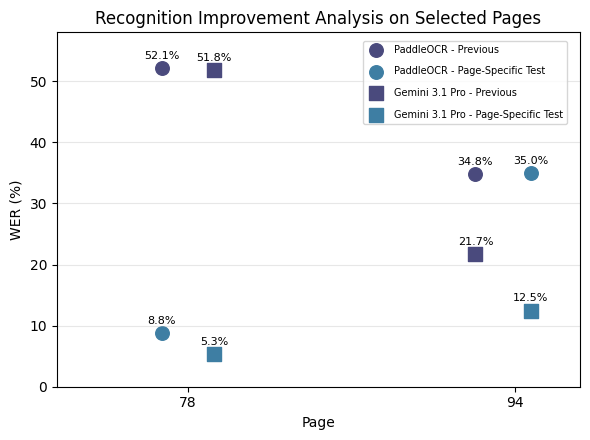

In [135]:
plt.figure(figsize=(6, 4.5))

page_positions = {
    78: 0,
    94: 0.10
}


colors = {
    "Previous": "#4a4a7d",
    #"Previous": "#003f5c",
    "Improved": "#3E7EA3"
}


label_names = {
    "Previous": "Previous",
    "Improved": "Page-Specific Test"
}

series = [
    ("PaddleOCR", "Previous", "o"),
    ("PaddleOCR", "Improved", "o"),
    ("Gemini 3.1 Pro", "Previous", "s"),
    ("Gemini 3.1 Pro", "Improved", "s")
]

point_offsets = {
    # Page 78
    (78, "PaddleOCR", "Previous"): -0.008,
    (78, "PaddleOCR", "Improved"): -0.008,
    (78, "Gemini 3.1 Pro", "Previous"): 0.008,
    (78, "Gemini 3.1 Pro", "Improved"): 0.008,

    # Page 94
    (94, "PaddleOCR", "Previous"): -0.012,
    (94, "PaddleOCR", "Improved"): 0.005,
    (94, "Gemini 3.1 Pro", "Previous"): -0.012,
    (94, "Gemini 3.1 Pro", "Improved"): 0.005
}

for model, condition, marker in series:

    subset = df_comparison[
        (df_comparison["Model"] == model) &
        (df_comparison["Condition"] == condition)
    ].copy()

    subset["x"] = subset["Page"].map(page_positions)

    first_point = True

    for _, row in subset.iterrows():

        offset = point_offsets[
            (row["Page"], model, condition)
        ]

        x_pos = row["x"] + offset

        plt.scatter(
            x_pos,
            row["WER (%)"],
            marker=marker,
            s=95,
            color=colors[condition],
            label=f"{model} - {label_names[condition]}"
            if first_point else None
        )

        plt.text(
            x_pos,
            row["WER (%)"] + 1.5,
            f'{row["WER (%)"]:.1f}%',
            ha="center",
            fontsize=8
        )

        first_point = False

plt.xlabel("Page")
plt.ylabel("WER (%)")
plt.title("Recognition Improvement Analysis on Selected Pages")

plt.xticks(
    [0, 0.10],
    ["78", "94"]
)

plt.xlim(-0.04, 0.12)
plt.ylim(0, 58)

plt.grid(axis="y", alpha=0.3)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.78, 0.99),
    fontsize=7,
    ncol=1,
    labelspacing=1.2
)

plt.tight_layout()
save_path = "wer_page_specific_test.pdf"

plt.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight"
)
plt.show()